In [ ]:
# ==========================================================
# STEP 1 — Install Kaggle CLI and Set Up Access
# ==========================================================
!pip install -q kaggle

# 🔹 Upload your Kaggle API token (kaggle.json)
# You can find it at: https://www.kaggle.com/<your-username>/account → Create API Token
from google.colab import files
files.upload()  # upload kaggle.json

# 🔹 Move it into ~/.kaggle and set permissions
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
# ==========================================================
# STEP 2 — Download and Extract Dataset from Kaggle
# ==========================================================
!kaggle datasets download -d sebastianpalaciob/plantvillage-for-object-detection-yolo -p /content

# Unzip
!unzip -q /content/plantvillage-for-object-detection-yolo.zip -d /content/PlantVillage_dataset


Dataset URL: https://www.kaggle.com/datasets/sebastianpalaciob/plantvillage-for-object-detection-yolo
License(s): CC-BY-NC-SA-4.0
 99% 821M/829M [00:07<00:00, 101MB/s] 
100% 829M/829M [00:07<00:00, 117MB/s]


In [ ]:
# ==========================================================
# STEP 3 — Setup Paths and Imports
# ==========================================================
import os, shutil
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt

images_path = "/content/PlantVillage_dataset/PlantVillage_for_object_detection/Dataset/images"
labels_path = "/content/PlantVillage_dataset/PlantVillage_for_object_detection/Dataset/labels"
output_dataset_path = "/content/tomato_yolo_dataset"

# Create output dirs
os.makedirs(f"{output_dataset_path}/images/train", exist_ok=True)
os.makedirs(f"{output_dataset_path}/images/val", exist_ok=True)
os.makedirs(f"{output_dataset_path}/labels/train", exist_ok=True)
os.makedirs(f"{output_dataset_path}/labels/val", exist_ok=True)


In [ ]:
# ==========================================================
# STEP 4 — Filter for Tomato Classes and Remap IDs
# ==========================================================
all_classes = [
    "Apple__Apple_scab", "Apple_Black_rot", "Apple_Cedar_apple_rust", "Apple__healthy",
    "Blueberry__healthy", "Cherry_Powdery_mildew", "Cherry__healthy",
    "Corn__Cercospora_leaf_spot Gray_leaf_spot", "Corn_Common_rust", "Corn_Northern_Leaf_Blight", "Corn__healthy",
    "Grape__Black_rot", "Grape_Esca(Black_Measles)", "Grape__Leaf_blight(Isariopsis_Leaf_Spot)", "Grape___healthy",
    "Orange__Haunglongbing(Citrus_greening)", "Peach__Bacterial_spot", "Peach__healthy",
    "Pepper,bell_Bacterial_spot", "Pepper,_bell__healthy",
    "Potato__Early_blight", "Potato_Late_blight", "Potato__healthy",
    "Raspberry__healthy", "Soybean_healthy", "Squash__Powdery_mildew",
    "Strawberry__Leaf_scorch", "Strawberry__healthy",
    "Tomato__Bacterial_spot", "Tomato_Early_blight", "Tomato__Late_blight",
    "Tomato__Leaf_Mold", "Tomato__Septoria_leaf_spot",
    "Tomato__Spider_mites Two-spotted_spider_mite", "Tomato__Target_Spot",
    "Tomato__Tomato_Yellow_Leaf_Curl_Virus", "Tomato__Tomato_mosaic_virus",
    "Tomato___healthy",
]

tomato_classes = [c for c in all_classes if c.startswith("Tomato")]
original_tomato_class_ids = [i for i, c in enumerate(all_classes) if c in tomato_classes]
class_id_mapping = {old_id: new_id for new_id, old_id in enumerate(original_tomato_class_ids)}

print(f"✅ Found {len(tomato_classes)} tomato classes:\n{tomato_classes}")


✅ Found 10 tomato classes:
['Tomato__Bacterial_spot', 'Tomato_Early_blight', 'Tomato__Late_blight', 'Tomato__Leaf_Mold', 'Tomato__Septoria_leaf_spot', 'Tomato__Spider_mites Two-spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_Yellow_Leaf_Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
# ==========================================================
# STEP 5 — Filter Labels for Tomato Images
# ==========================================================
def filter_and_remap_annotations(label_file_path, id_mapping):
    new_annotations = []
    if not os.path.exists(label_file_path):
        return None
    with open(label_file_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) > 0:
            original_class_id = int(parts[0])
            if original_class_id in id_mapping:
                parts[0] = str(id_mapping[original_class_id])
                new_annotations.append(" ".join(parts))
    return new_annotations

all_label_files = os.listdir(labels_path)
tomato_image_names = []

for label_file in all_label_files:
    annotations = filter_and_remap_annotations(os.path.join(labels_path, label_file), class_id_mapping)
    if annotations:
        tomato_image_names.append(os.path.splitext(label_file)[0])

print(f"✅ Found {len(tomato_image_names)} tomato-related images.")


✅ Found 18158 tomato-related images.


In [ ]:
# ==========================================================
# STEP 6 — Split Train/Val and Copy Files
# ==========================================================
train_names, val_names = train_test_split(tomato_image_names, test_size=0.2, random_state=42)
print(f"Training: {len(train_names)}, Validation: {len(val_names)}")

def setup_dataset_split(image_names, split_type):
    for name in image_names:
        src_img_path = os.path.join(images_path, f"{name}.jpg")
        if not os.path.exists(src_img_path):
            src_img_path = os.path.join(images_path, f"{name}.JPG")
        if not os.path.exists(src_img_path):
            continue

        dst_img_path = os.path.join(output_dataset_path, 'images', split_type, os.path.basename(src_img_path))
        shutil.copy(src_img_path, dst_img_path)

        src_label_path = os.path.join(labels_path, f"{name}.txt")
        remapped_annotations = filter_and_remap_annotations(src_label_path, class_id_mapping)
        if remapped_annotations:
            dst_label_path = os.path.join(output_dataset_path, 'labels', split_type, f"{name}.txt")
            with open(dst_label_path, 'w') as f:
                f.write("\n".join(remapped_annotations))

setup_dataset_split(train_names, 'train')
setup_dataset_split(val_names, 'val')

print("✅ Dataset prepared successfully at:", output_dataset_path)


Training: 14526, Validation: 3632
✅ Dataset prepared successfully at: /content/tomato_yolo_dataset



TRAINING SET - CLASS DISTRIBUTION
Total images: 14526
Total annotations: 14541
Images with multiple classes: 0

Class ID  Class Name                                   Count     
0         Tomato__Bacterial_spot                       1700      (11.7%)
1         Tomato_Early_blight                          785       (5.4%)
2         Tomato__Late_blight                          1531      (10.5%)
3         Tomato__Leaf_Mold                            761       (5.2%)
4         Tomato__Septoria_leaf_spot                   1431      (9.8%)
5         Tomato__Spider_mites Two-spotted_spider_mite 1356      (9.3%)
6         Tomato__Target_Spot                          1113      (7.7%)
7         Tomato__Tomato_Yellow_Leaf_Curl_Virus        4277      (29.4%)
8         Tomato__Tomato_mosaic_virus                  301       (2.1%)
9         Tomato___healthy                             1286      (8.8%)


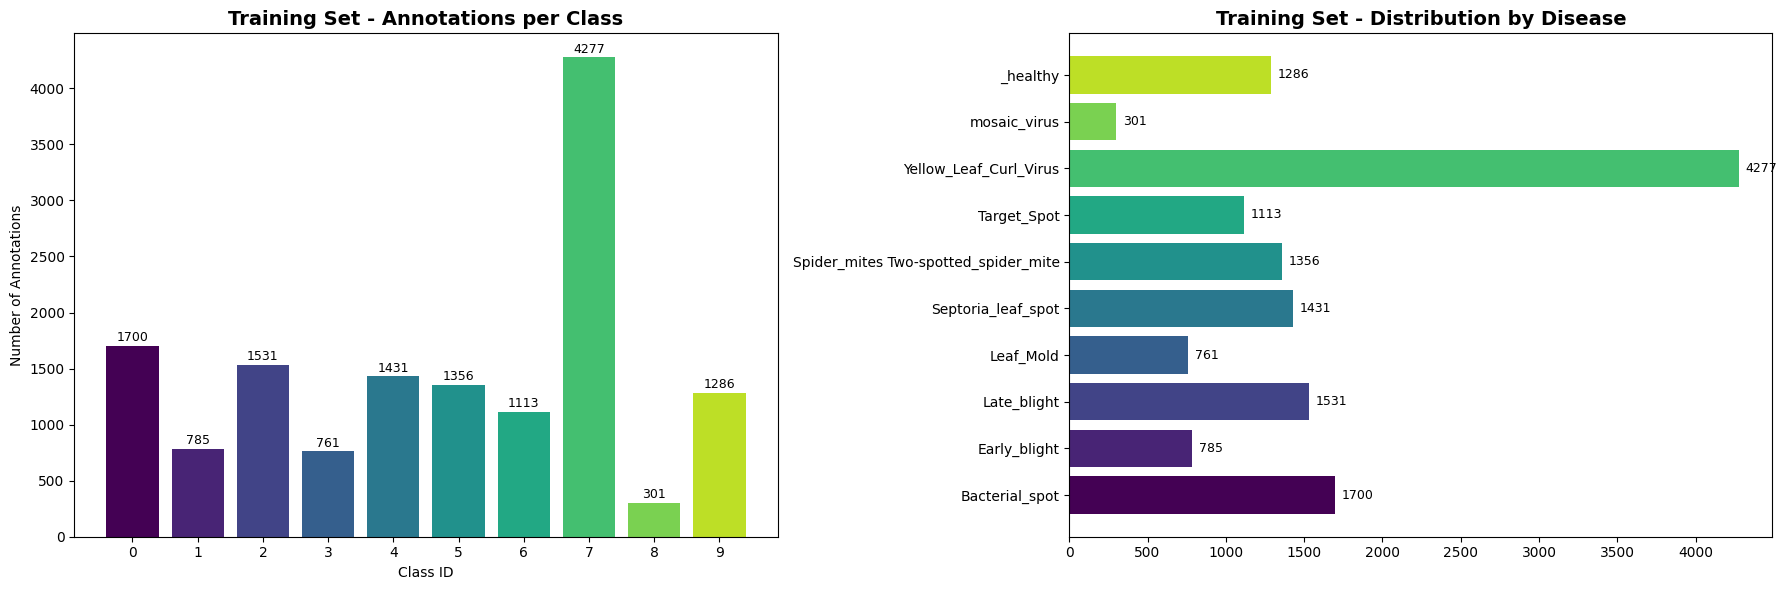


Most frequent class: Tomato__Tomato_Yellow_Leaf_Curl_Virus (4277)
Least frequent class: Tomato__Tomato_mosaic_virus (301)
Imbalance ratio: 14.21:1
⚠️  Significant imbalance detected. Consider weighted loss or augmentation.

VALIDATION SET - CLASS DISTRIBUTION
Total images: 3632
Total annotations: 3638
Images with multiple classes: 0

Class ID  Class Name                                   Count     
0         Tomato__Bacterial_spot                       427       (11.7%)
1         Tomato_Early_blight                          219       (6.0%)
2         Tomato__Late_blight                          380       (10.4%)
3         Tomato__Leaf_Mold                            191       (5.3%)
4         Tomato__Septoria_leaf_spot                   347       (9.5%)
5         Tomato__Spider_mites Two-spotted_spider_mite 321       (8.8%)
6         Tomato__Target_Spot                          292       (8.0%)
7         Tomato__Tomato_Yellow_Leaf_Curl_Virus        1084      (29.8%)
8         Tomato__

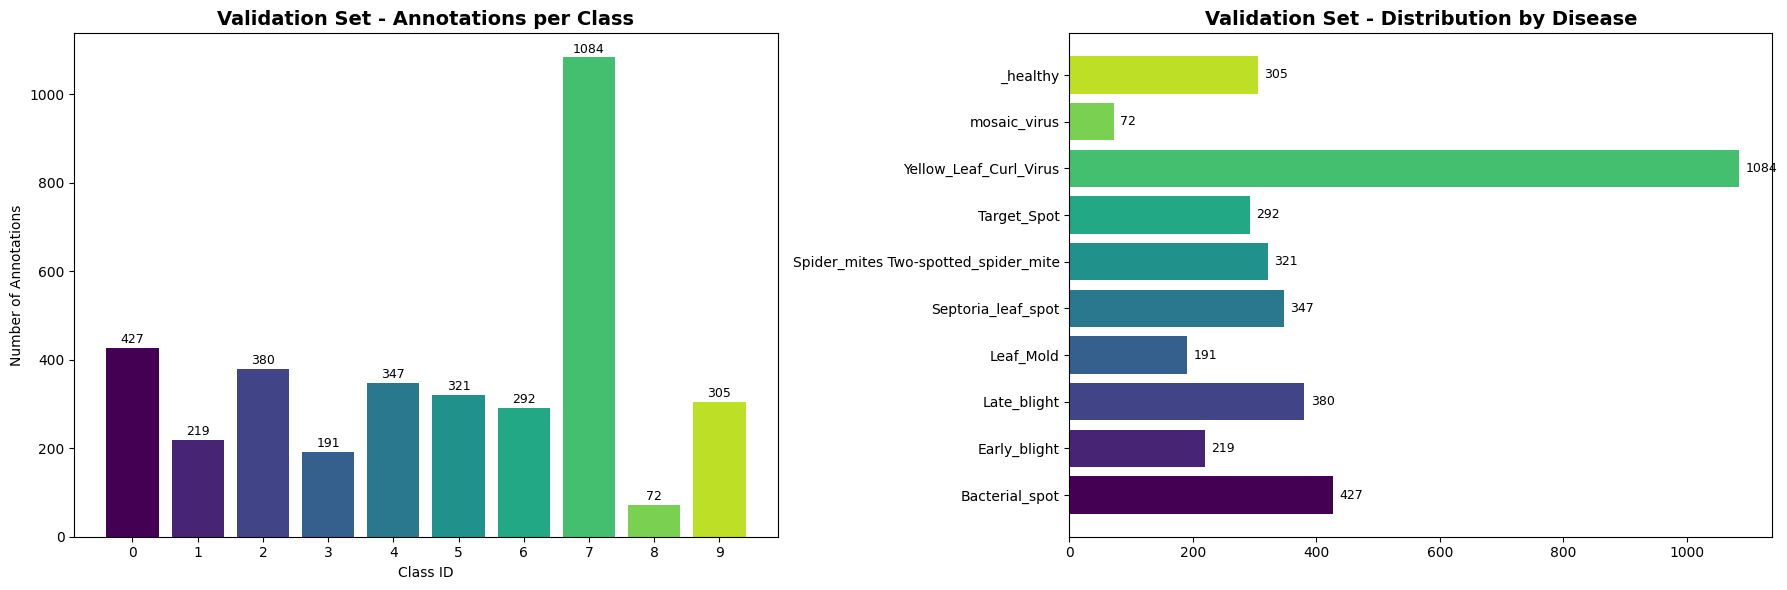


Most frequent class: Tomato__Tomato_Yellow_Leaf_Curl_Virus (1084)
Least frequent class: Tomato__Tomato_mosaic_virus (72)
Imbalance ratio: 15.06:1
⚠️  Significant imbalance detected. Consider weighted loss or augmentation.


In [ ]:
# ==========================================================
# STEP 7 — Analyze Class Distribution (Train + Val)
# ==========================================================
def analyze_distribution(labels_dir, split_name):
    tomato_class_names = [
        'Tomato__Bacterial_spot', 'Tomato_Early_blight', 'Tomato__Late_blight',
        'Tomato__Leaf_Mold', 'Tomato__Septoria_leaf_spot',
        'Tomato__Spider_mites Two-spotted_spider_mite', 'Tomato__Target_Spot',
        'Tomato__Tomato_Yellow_Leaf_Curl_Virus', 'Tomato__Tomato_mosaic_virus',
        'Tomato___healthy'
    ]
    class_counts = Counter()
    images_with_multiple_classes = 0
    total_annotations = 0

    label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
    for label_file in label_files:
        classes_in_image = set()
        with open(os.path.join(labels_dir, label_file)) as f:
            lines = f.readlines()
            total_annotations += len(lines)
            for line in lines:
                cid = int(line.strip().split()[0])
                class_counts[cid] += 1
                classes_in_image.add(cid)
        if len(classes_in_image) > 1:
            images_with_multiple_classes += 1

    print(f"\n{'='*70}\n{split_name.upper()} SET - CLASS DISTRIBUTION\n{'='*70}")
    print(f"Total images: {len(label_files)}")
    print(f"Total annotations: {total_annotations}")
    print(f"Images with multiple classes: {images_with_multiple_classes}")
    print(f"\n{'Class ID':<10}{'Class Name':<45}{'Count':<10}")
    print("="*70)
    for i, name in enumerate(tomato_class_names):
        count = class_counts.get(i, 0)
        perc = (count / total_annotations * 100) if total_annotations else 0
        print(f"{i:<10}{name:<45}{count:<10}({perc:.1f}%)")
    print("="*70)

    # Plot
    counts = [class_counts.get(i, 0) for i in range(len(tomato_class_names))]
    colors = plt.cm.viridis([i/len(tomato_class_names) for i in range(len(tomato_class_names))])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    ax1.bar(range(len(counts)), counts, color=colors)
    ax1.set_title(f"{split_name.capitalize()} Set - Annotations per Class", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Class ID")
    ax1.set_ylabel("Number of Annotations")
    ax1.set_xticks(range(len(counts)))
    for i, c in enumerate(counts):
        ax1.text(i, c + max(counts)*0.01, str(c), ha='center', fontsize=9)

    short_names = [n.replace('Tomato__', '').replace('Tomato_', '') for n in tomato_class_names]
    ax2.barh(short_names, counts, color=colors)
    ax2.set_title(f"{split_name.capitalize()} Set - Distribution by Disease", fontsize=14, fontweight='bold')
    for i, c in enumerate(counts):
        ax2.text(c + max(counts)*0.01, i, str(c), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'/content/class_distribution_{split_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Imbalance check
    if counts:
        max_c, min_c = max(counts), min([c for c in counts if c > 0])
        ratio = max_c / min_c if min_c > 0 else float('inf')
        print(f"\nMost frequent class: {tomato_class_names[counts.index(max_c)]} ({max_c})")
        print(f"Least frequent class: {tomato_class_names[counts.index(min_c)]} ({min_c})")
        print(f"Imbalance ratio: {ratio:.2f}:1")
        if ratio > 10:
            print("⚠️  Significant imbalance detected. Consider weighted loss or augmentation.")
        elif ratio > 5:
            print("⚠️  Moderate imbalance detected.")
        else:
            print("✅ Class distribution relatively balanced.")

# Analyze both sets
analyze_distribution(f"{output_dataset_path}/labels/train", "Training")
analyze_distribution(f"{output_dataset_path}/labels/val", "Validation")


In [ ]:
import shutil
from IPython.display import FileLink

# ==========================================================
# 1️⃣ ZIP the Tomato-only Dataset
# ==========================================================
tomato_zip_path = "/content/tomato_yolo_dataset.zip"
shutil.make_archive("/content/tomato_yolo_dataset", 'zip', "/content/tomato_yolo_dataset")

print("✅ Tomato dataset zipped successfully!")
display(FileLink(tomato_zip_path))  # click link to download


# ==========================================================
# 2️⃣ ZIP the Original PlantVillage Dataset
# ==========================================================
plant_zip_path = "/content/PlantVillage_for_object_detection.zip"
shutil.make_archive("/content/PlantVillage_for_object_detection", 'zip',
                    "/content/PlantVillage_dataset/PlantVillage_for_object_detection")

print("✅ Original PlantVillage dataset zipped successfully!")
display(FileLink(plant_zip_path))  # click link to download


✅ Tomato dataset zipped successfully!


/content/tomato_yolo_dataset.zip

✅ Original PlantVillage dataset zipped successfully!


/content/PlantVillage_for_object_detection.zip